<a href="https://colab.research.google.com/github/Manas-Siddharth/Deep-Learning/blob/main/2b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Import Libraries and Load Pre-trained Base Model

First, we import TensorFlow and Keras, along with the `MobileNetV2` application. We'll load the base model without its top (classification) layers, as we'll be adding our own.

In [ ]:
# Define global parameters for image loading and processing
IMG_HEIGHT = 160 # A common size, can be adjusted
IMG_WIDTH = 160  # A common size, can be adjusted
BATCH_SIZE = 32

print(f"Global image dimensions set to: {IMG_HEIGHT}x{IMG_WIDTH}")

Global image dimensions set to: 160x160


### Custom Model with Dataset from ZIP file

First, we'll extract the dataset from the uploaded zip file and prepare it for training a custom CNN model.

In [ ]:
import zipfile
import os
import tensorflow as tf
import numpy as np

# Define the path to your zip file
zip_file_path = '/content/archive (9).zip'

# Define the directory where you want to extract the contents
extraction_path = '/content/dataset/'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Check if the zip file exists
if not os.path.exists(zip_file_path):
    raise FileNotFoundError(f"The zip file '{zip_file_path}' was not found. Please upload it to your Colab environment or verify the path.")

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Dataset extracted to: {extraction_path}")

# List the contents of the extracted directory to understand its structure
extracted_contents = os.listdir(extraction_path)
print("Contents of extracted directory:", extracted_contents)

# Assuming the dataset structure is 'dataset_root/class_name/images.jpg'
# We'll try to find the actual root directory of the images
data_root = extraction_path
if len(extracted_contents) == 1 and os.path.isdir(os.path.join(extraction_path, extracted_contents[0])):
    data_root = os.path.join(extraction_path, extracted_contents[0])
    print(f"Adjusted data_root to: {data_root}")


# Load the dataset using image_dataset_from_directory
# We'll split it into training and validation sets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_root,validation_split=0.2,subset="training",seed=123,image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_root,validation_split=0.2,subset="validation",seed=123,image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)

# Get class names
class_names = train_ds.class_names
print("Class names:", class_names)
print(f"Number of classes: {len(class_names)}")

# Configure the dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Normalize pixel values to [0, 1]
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

print("Dataset prepared successfully!")

Dataset extracted to: /content/dataset/
Contents of extracted directory: ['Combined Dataset']
Adjusted data_root to: /content/dataset/Combined Dataset
Found 11519 files belonging to 2 classes.
Using 9216 files for training.
Found 11519 files belonging to 2 classes.
Using 2303 files for validation.
Class names: ['test', 'train']
Number of classes: 2
Dataset prepared successfully!


### Define a Manual CNN Model

Now, let's build a simple convolutional neural network from scratch using `tf.keras.Sequential`.

In [ ]:
num_classes = len(class_names)

manual_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

manual_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,402,050 (20.61 MB)

 Trainable params: 5,402,050 (20.61 MB)

 Non-trainable params: 0 (0.00 B)

### Compile and Train the Manual Model

We'll compile the custom model with an optimizer, loss function, and metrics, and then train it using the prepared dataset.

In [ ]:
manual_model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
metrics=['accuracy'])
epochs = 10 # Adjusted for better visualization of training history
history = manual_model.fit(train_ds,validation_data=val_ds,epochs=epochs)

print("Manual model training complete!")

Epoch 1/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.8870 - loss: 0.3295 - val_accuracy: 0.8962 - val_loss: 0.3034
Epoch 2/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.8870 - loss: 0.3114 - val_accuracy: 0.8962 - val_loss: 0.2909
Epoch 3/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.8873 - loss: 0.2978 - val_accuracy: 0.8962 - val_loss: 0.2870
Epoch 4/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.8868 - loss: 0.2857 - val_accuracy: 0.8962 - val_loss: 0.2953
Epoch 5/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.8876 - loss: 0.2796 - val_accuracy: 0.8958 - val_loss: 0.2921
Epoch 6/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.8867 - loss: 0.2728 - val_accuracy: 0.8958 - val_loss: 0.2880
Epoch 7/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.8856 - loss: 0.2628 - val_accuracy: 0.8906 - val_loss: 0.2938
Epoch 8/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.8907 - loss: 0.2576 - val_acc

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

# Define input shape suitable for MobileNetV2, matching the dataset's image size
IMG_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3) # Using IMG_HEIGHT and IMG_WIDTH from data loading

# Load the pre-trained MobileNetV2 model without the top classification layer
base_model = MobileNetV2(input_shape=IMG_SHAPE,include_top=False,weights='imagenet')

# Display the base model summary
print("Base Model Summary:")
base_model.summary()

Base Model Summary:


Model: "mobilenetv2_1.00_160"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

### 2. Freeze the Base Model Layers

It's important to freeze the base model's layers so that their weights are not updated during the initial training of the new classification head. This prevents destroying the learned features.

In [ ]:
# Freeze the base model to prevent its weights from being updated during training
base_model.trainable = False

print(f"Is base_model trainable? {base_model.trainable}")

Is base_model trainable? False


### 3. Add a Custom Classification Head

Now we'll build our own classification head on top of the frozen base model. This typically involves a Global Average Pooling layer, one or more Dense layers, and an output Dense layer with an activation function appropriate for your task (e.g., `softmax` for multi-class classification, `sigmoid` for binary classification).

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

# Create a new model on top of the frozen base model

# Get the output of the base model
inputs = keras.Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)

# Add a Global Average Pooling 2D layer
x = layers.GlobalAveragePooling2D()(x)

# Add a dense classification layer
num_classes = len(class_names) # Use the number of classes from the loaded dataset
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Construct the new model
model = keras.Model(inputs, outputs)

# Display the new model summary
print("\nModel with Custom Classification Head Summary:")
model.summary()


Model with Custom Classification Head Summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 4. Compile the Model

Before training, the model needs to be compiled. You'll specify the optimizer, loss function, and metrics relevant to your task.

In [ ]:
# Compile the model
model.compile(optimizer=keras.optimizers.Adam(),loss=keras.losses.SparseCategoricalCrossentropy(),metrics=['accuracy'])
print("Model compiled successfully!")

Model compiled successfully!


### 5. Prepare a Custom Target Dataset (Placeholder)

To fine-tune the model, you'll need to load and preprocess your custom dataset. This typically involves loading images, resizing them to `IMG_SHAPE`, and batching them. Below is a placeholder for how you might load data using `tf.keras.preprocessing.image_dataset_from_directory` or `tf.data.Dataset`.

### 6. Train the Classification Head (Fine-tuning Stage 1)

Now, you can train the newly added classification head with your custom dataset while the base model remains frozen. This helps the new layers learn to interpret the features extracted by the pre-trained model.

In [ ]:
# Train the MobileNetV2 model with the custom classification head
# Replace `train_ds` and `val_ds` with your actual dataset variables.

epochs = 10 # Adjusted for better visualization of training history
history_mobilenet = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds
)

print("MobileNetV2 model training complete!")

Epoch 1/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8851 - loss: 0.3135 - val_accuracy: 0.8958 - val_loss: 0.2896
Epoch 2/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.8862 - loss: 0.3059 - val_accuracy: 0.8962 - val_loss: 0.2922
Epoch 3/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8862 - loss: 0.2996 - val_accuracy: 0.8962 - val_loss: 0.2982
Epoch 4/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8853 - loss: 0.2957 - val_accuracy: 0.8945 - val_loss: 0.2914
Epoch 5/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8855 - loss: 0.2949 - val_accuracy: 0.8962 - val_loss: 0.2933
Epoch 6/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8849 - loss: 0.2931 - val_accuracy: 0.8958 - val_loss: 0.2892
Epoch 7/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8857 - loss: 0.2908 - val_accuracy: 0.8862 - val_loss: 0.3016
Epoch 8/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.8857 - loss: 0.2883 - val_ac

### 7. Compare Model Accuracies

Finally, let's evaluate both models on the validation set and compare their final accuracies.

In [ ]:
print("\n--- Evaluating Manual Model ---")
loss_manual, accuracy_manual = manual_model.evaluate(val_ds)
print(f"Manual Model - Validation Accuracy: {accuracy_manual:.4f}")

print("\n--- Evaluating MobileNetV2 Model ---")
loss_mobilenet, accuracy_mobilenet = model.evaluate(val_ds)
print(f"MobileNetV2 Model - Validation Accuracy: {accuracy_mobilenet:.4f}")

print("\n--- Comparison ---")
if accuracy_mobilenet > accuracy_manual:
    print(f"The MobileNetV2 model performed better with an accuracy of {accuracy_mobilenet:.4f} compared to the manual model's {accuracy_manual:.4f}.")
elif accuracy_manual > accuracy_mobilenet:
    print(f"The Manual Model performed better with an accuracy of {accuracy_manual:.4f} compared to the MobileNetV2 model's {accuracy_mobilenet:.4f}.")
else:
    print(f"Both models achieved the same accuracy of {accuracy_manual:.4f}.")


--- Evaluating Manual Model ---
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8962 - loss: 0.3159
Manual Model - Validation Accuracy: 0.8962

--- Evaluating MobileNetV2 Model ---
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8954 - loss: 0.2963
MobileNetV2 Model - Validation Accuracy: 0.8954

--- Comparison ---
The Manual Model performed better with an accuracy of 0.8962 compared to the MobileNetV2 model's 0.8954.


### Visualize Training History

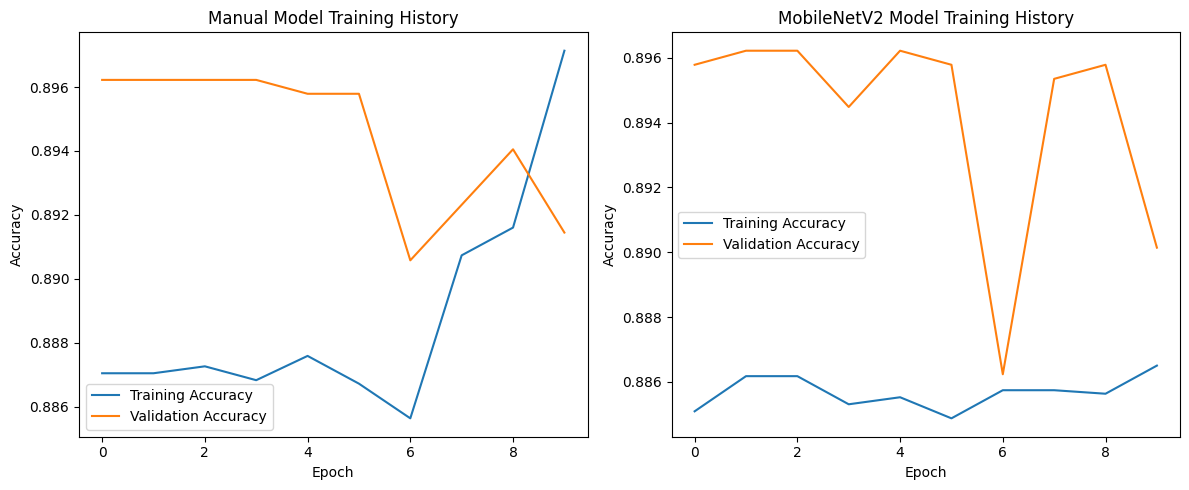

In [ ]:
import matplotlib.pyplot as plt

# Plot training history for the Manual Model
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Manual Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training history for the MobileNetV2 Model
plt.subplot(1, 2, 2)
plt.plot(history_mobilenet.history['accuracy'], label='Training Accuracy')
plt.plot(history_mobilenet.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()